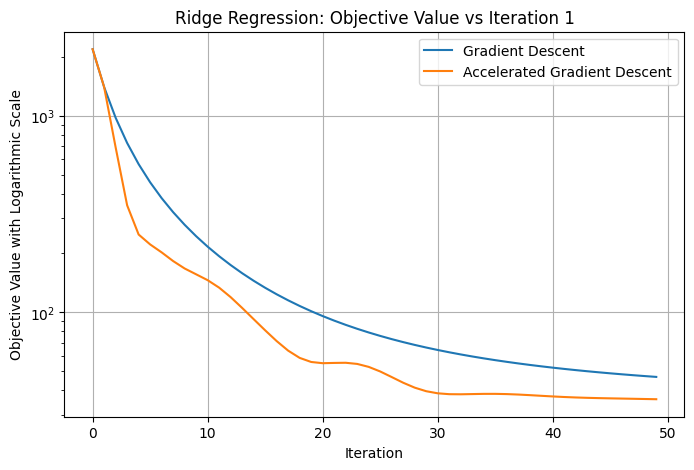

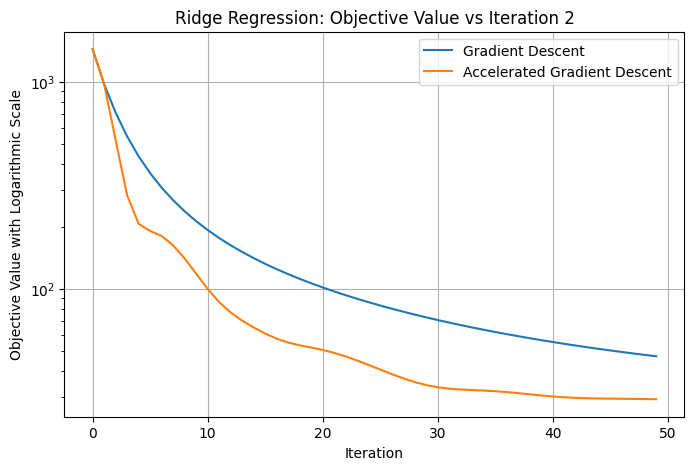

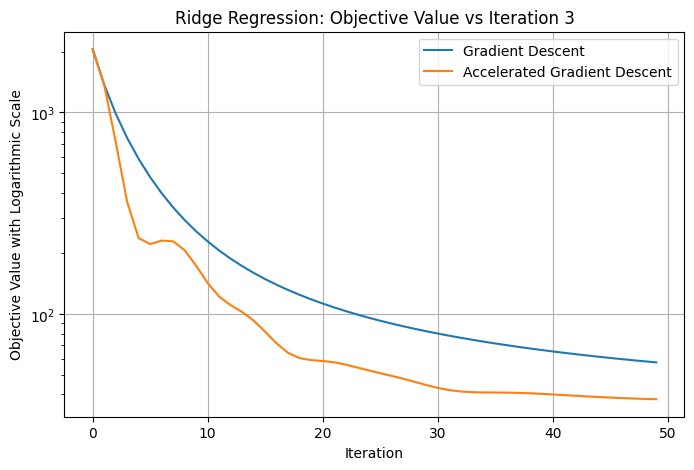

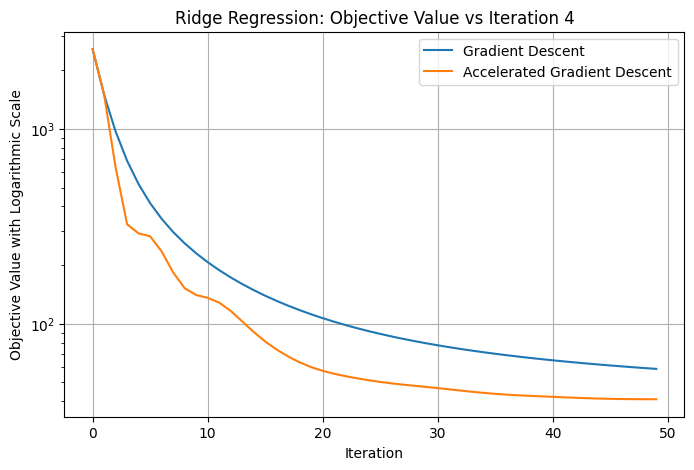

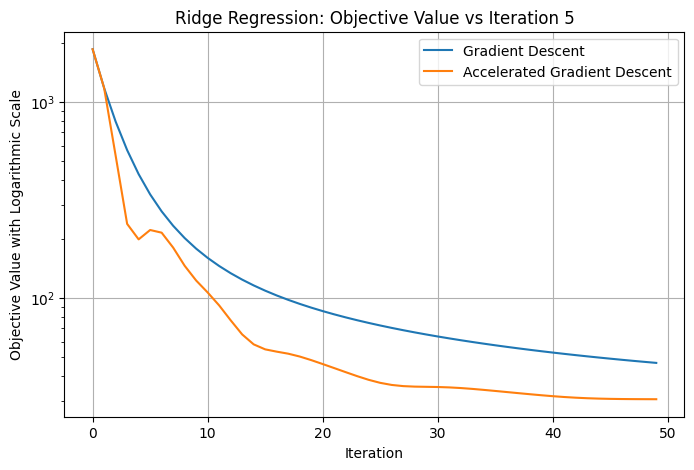

In [18]:
import numpy as np
import scipy
import cvxpy as cp
import matplotlib.pyplot as plt
import math

def ridge_objective(x, A, y, lmbda):
    return 0.5 * np.linalg.norm(A @ x - y)**2 + 0.5 * lmbda * np.linalg.norm(x)**2

def gradient_descent(A, y, lmbda, beta, num_iters=50):
    n = A.shape[1]
    x = np.zeros(n)
    f_values = []
    alpha = 1 / beta  #Step size

    for k in range(num_iters):
        grad = A.T @ (A @ x - y) + lmbda * x
        x = x - alpha * grad
        f_values.append(ridge_objective(x, A, y, lmbda))
    return f_values

def accelerated_gradient_descent(A, y, lmbda, beta, num_iters=50):
    n = A.shape[1]
    x = np.zeros(n)
    z = np.zeros(n)
    f_values = []
    alpha = 1 / beta  #Step size
    gamma = 0
    for k in range(num_iters):
        prev_x = x.copy()
        grad = A.T @ (A @ z - y) + lmbda * z
        x = z - alpha * grad
        if k == 0:
            gamma = 0
        else:
            gamma = (np.sqrt(beta) - np.sqrt(lmbda)) / (np.sqrt(beta) + np.sqrt(lmbda))
        z = x + gamma * (x - prev_x)
        f_values.append(ridge_objective(x, A, y, lmbda))
    return f_values

for i in range(5): #For loop here to show that answers vary
    n = 100
    m = 80
    lmbda = 1
    x_opt = np.random.randn(n)
    A = np.random.randn(m, n)
    myVariance = 0.25
    mySTD = math.sqrt(myVariance)
    epsilon = np.random.normal(0, mySTD, m)
    y = A @ x_opt + epsilon
    beta = 4*(m+n) + lmbda
    
    gd_values = gradient_descent(A, y, lmbda, beta, num_iters=50)
    agd_values = accelerated_gradient_descent(A, y, lmbda, beta, num_iters=50)

    plt.figure(figsize=(8, 5))
    plt.semilogy(gd_values, label = "Gradient Descent")
    plt.semilogy(agd_values, label = "Accelerated Gradient Descent")
    plt.xlabel("Iteration")
    plt.ylabel("Objective Value with Logarithmic Scale")
    plt.title("Ridge Regression: Objective Value vs Iteration "+str(i+1))
    plt.legend()
    plt.grid(True)
    plt.show()